# EDA 02 — Road Closures

**Data source**: `road-closures` Azure Blob Storage container  
**Loaded by**: `src/data_loader.load_road_closures(START, END)`  
**Output**: `data/processed/road_closures_clean.parquet` consumed by the main analysis notebook

This notebook performs a complete exploratory analysis of the raw road closure dataset before any spatial or temporal joining takes place. The goal is to understand the structure, quality and operational characteristics of road closures as a standalone source, and to document any cleaning decisions before the data enters the modelling pipeline.

---
**Sections**
1. Load and inspect raw data  
2. Missing value audit  
3. Closure type and validity status  
4. Cause type and source breakdown  
5. Temporal distribution (when do closures occur?)  
6. Duration analysis (how long do closures last?)  
7. Spatial distribution (where do closures occur?)  
8. Lanes closed distribution  
9. Save cleaned output  


## 0. Setup

In [93]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_01", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Inspect Raw Data

In [94]:
from datetime import datetime, timezone
from src.data_loader import load_road_closures

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 12, 23, 59, 59, tzinfo=timezone.utc)

road_df = load_road_closures(START, END)
print(f"Shape: {road_df.shape}")
print(f"Columns: {list(road_df.columns)}")

Using 4 local files within the time window.
Shape: (296, 14)
Columns: ['situation_id', 'record_id', 'start_time', 'end_time', 'validity_status', 'cause_type', 'source', 'road_name', 'lanes_closed', 'closure_lat', 'closure_lon', 'poslist', 'ingestion_time', 'closure_type']


In [95]:
# Full dtypes and non-null counts
road_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   situation_id     296 non-null    object 
 1   record_id        296 non-null    object 
 2   start_time       296 non-null    object 
 3   end_time         296 non-null    object 
 4   validity_status  296 non-null    object 
 5   cause_type       296 non-null    object 
 6   source           296 non-null    object 
 7   road_name        296 non-null    object 
 8   lanes_closed     296 non-null    int64  
 9   closure_lat      296 non-null    float64
 10  closure_lon      296 non-null    float64
 11  poslist          296 non-null    object 
 12  ingestion_time   296 non-null    object 
 13  closure_type     296 non-null    object 
dtypes: float64(2), int64(1), object(11)
memory usage: 32.5+ KB


In [96]:
# First few rows
road_df.head()

,situation_id,record_id,start_time,end_time,validity_status,cause_type,source,road_name,lanes_closed,closure_lat,closure_lon,poslist,ingestion_time,closure_type
0,481398,1-1770230430-d6ff48ca-8971-4f31-831f-272231753b8a,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,M11,2,52.241032,0.056728,['52.237974 0.062705 52.237644 0.063174 52.237...,2026-04-11 05:09:20.728518,planned
1,481398,1-1770230430-ee17da45-7781-4cee-85b8-1958b86f1b72,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,A14,1,52.240029,0.059073,['52.240826 0.057497 52.240366 0.058604 52.239...,2026-04-11 05:09:20.728567,planned
2,481398,1-1770230430-acff749b-b497-4d6f-a60f-01677b02af5c,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,A14,2,52.260536,0.016397,['52.257609 0.023547 52.257608 0.023549 52.257...,2026-04-11 05:09:20.728631,planned
3,481533,1-1770819974-8fa8f569-45d0-4710-a6df-39f3d37e1c3d,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,M1,3,52.847611,-1.298524,['52.855638 -1.299951 52.855692 -1.299979 52.8...,2026-04-11 05:09:20.728723,planned
4,470844,1-1770730368-f293b6be-d3b5-410b-9fc8-9761a531e558,2026-04-10T08:00:00Z,2026-04-10T14:00:00Z,planned,roadMaintenance,roadworks,A36,1,51.075089,-1.787852,['51.075752 -1.790037 51.075673 -1.78978 51.07...,2026-04-11 05:09:20.728744,planned


In [97]:
# Descriptive statistics for numeric columns
road_df.describe()

,lanes_closed,closure_lat,closure_lon
count,296.000000,296.000000,296.000000
mean,1.145270,52.541169,-1.157017
std,1.139065,1.064926,1.041829
min,0.000000,50.235934,-5.258432
25%,0.000000,51.592669,-1.739951
50%,1.000000,52.430979,-1.209548
75%,2.000000,53.479986,-0.437912
max,4.000000,55.066364,1.722977


## 2. Missing Value Audit

Understanding which fields are missing and why is critical before joining this data with rail sources. Missing spatial coordinates would prevent station matching; missing temporal fields would prevent the 60-minute window filter from working correctly.

In [98]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    "missing_count": road_df.isna().sum(),
    "missing_pct": (road_df.isna().sum() / len(road_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

                 missing_count  missing_pct
situation_id                 0          0.0
record_id                    0          0.0
start_time                   0          0.0
end_time                     0          0.0
validity_status              0          0.0
cause_type                   0          0.0
source                       0          0.0
road_name                    0          0.0
lanes_closed                 0          0.0
closure_lat                  0          0.0
closure_lon                  0          0.0
poslist                      0          0.0
ingestion_time               0          0.0
closure_type                 0          0.0


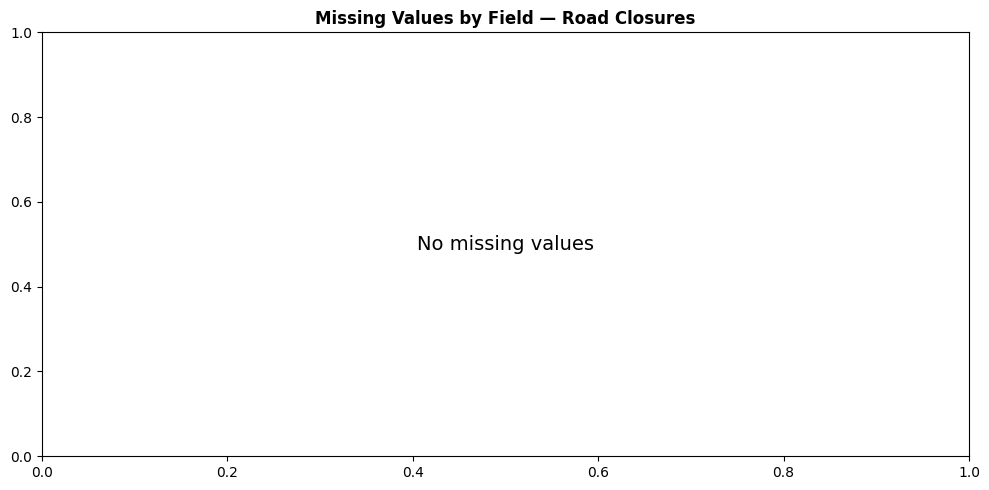

In [99]:
# Visualise missingness
fig, ax = plt.subplots(figsize=(10, 5))
missing_nonzero = missing[missing["missing_pct"] > 0]
if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"], color="tomato", edgecolor="black")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values by Field - Road Closures", fontweight="bold")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
    ax.set_title("Missing Values by Field — Road Closures", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_01/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

In [100]:
# Flag rows missing spatial coordinates — these cannot be spatially matched
missing_coords = road_df[road_df["closure_lat"].isna() | road_df["closure_lon"].isna()]
print(f"Rows missing spatial coordinates: {len(missing_coords):,} ({len(missing_coords)/len(road_df)*100:.1f}%)")

# Flag rows missing temporal bounds
missing_times = road_df[road_df["start_time"].isna() | road_df["end_time"].isna()]
print(f"Rows missing temporal bounds:     {len(missing_times):,} ({len(missing_times)/len(road_df)*100:.1f}%)")

Rows missing spatial coordinates: 0 (0.0%)
Rows missing temporal bounds:     0 (0.0%)


## 3. Closure Type and Validity Status

The `closure_type` field is derived from the filename at load time (planned vs unplanned). The `validity_status` field reflects the operational state of the closure at ingestion time.

In [101]:
# Closure type counts
print("=== Closure Type ===")
ct = road_df["closure_type"].value_counts()
print(ct.to_string())
print()

# Validity status counts
print("=== Validity Status ===")
vs = road_df["validity_status"].value_counts()
print(vs.to_string())

=== Closure Type ===
closure_type
planned      200
unplanned     96

=== Validity Status ===
validity_status
planned      186
suspended     96
active        14


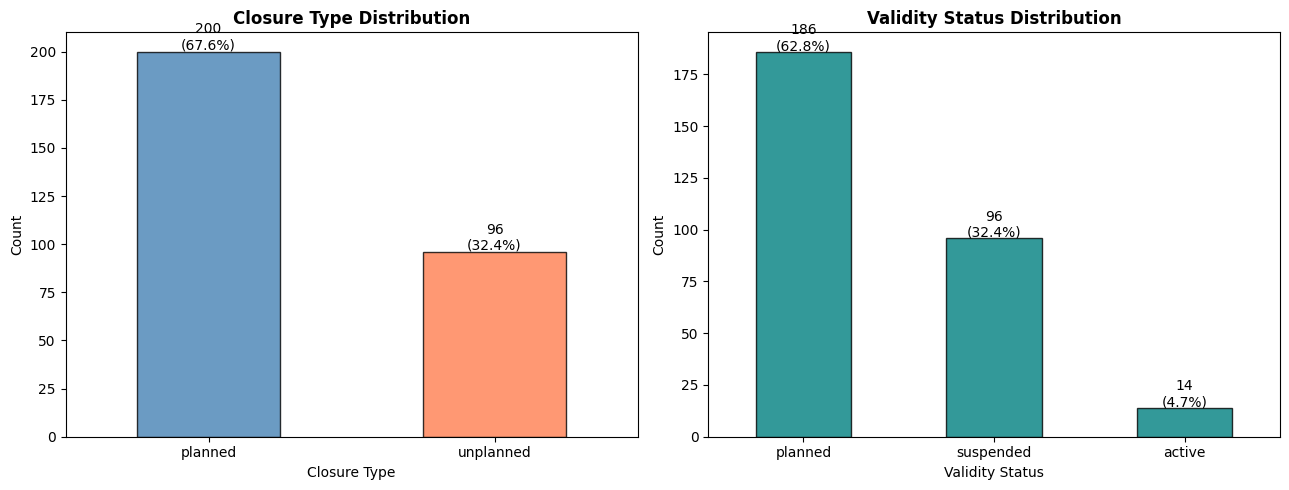

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Closure type
ct.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"],
        edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type Distribution", fontweight="bold")
axes[0].set_xlabel("Closure Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 1, f"{v:,}\n({v/len(road_df)*100:.1f}%)",
                 ha="center", fontsize=10)

# Validity status
vs.plot(kind="bar", ax=axes[1], color="teal", edgecolor="black", alpha=0.8)
axes[1].set_title("Validity Status Distribution", fontweight="bold")
axes[1].set_xlabel("Validity Status")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 0.5, f"{v:,}\n({v/len(road_df)*100:.1f}%)",
                 ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_01/closure_type_validity.png", dpi=200, bbox_inches="tight")
plt.show()

In [103]:
# Cross-tabulation: closure type vs validity status
ct_vs = pd.crosstab(road_df["closure_type"], road_df["validity_status"],
                    margins=True, margins_name="Total")
print(ct_vs.to_string())

validity_status  active  planned  suspended  Total
closure_type                                      
planned              14      186          0    200
unplanned             0        0         96     96
Total                14      186         96    296


## 4. Cause Type and Source Breakdown

`cause_type` indicates the reason for the closure (e.g. roadMaintenance, accident). `source` indicates the reporting system. Understanding these distributions informs which closure types are most relevant to rail disruption.

In [104]:
print("=== Cause Type ===")
cause = road_df["cause_type"].value_counts()
print(cause.to_string())
print()

print("=== Source ===")
source = road_df["source"].value_counts()
print(source.to_string())

=== Cause Type ===
cause_type
roadMaintenance                      160
roadOrCarriagewayOrLaneManagement     96
constructionWork                      32
authorityOperation                     8

=== Source ===
source
roadworks            200
Signs and Signals     96


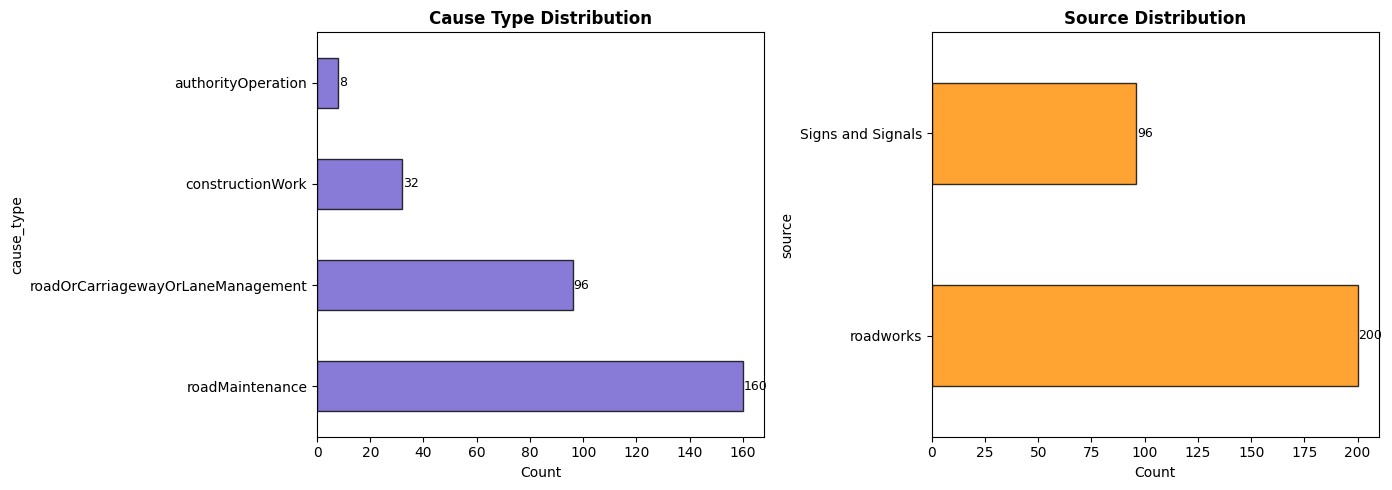

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cause.plot(kind="barh", ax=axes[0], color="slateblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Cause Type Distribution", fontweight="bold")
axes[0].set_xlabel("Count")
for i, v in enumerate(cause.values):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=9)

source.plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_title("Source Distribution", fontweight="bold")
axes[1].set_xlabel("Count")
for i, v in enumerate(source.values):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_01/cause_source.png", dpi=200, bbox_inches="tight")
plt.show()

In [106]:
# Cause type by closure type (planned vs unplanned)
cause_by_type = pd.crosstab(road_df["cause_type"], road_df["closure_type"])
print(cause_by_type.to_string())

closure_type                       planned  unplanned
cause_type                                           
authorityOperation                       8          0
constructionWork                        32          0
roadMaintenance                        160          0
roadOrCarriagewayOrLaneManagement        0         96


## 5. Temporal Distribution

Understanding when closures start and end reveals whether they concentrate in particular hours or days. This informs whether time-of-day features add value beyond closure type and proximity.

In [107]:
road_df["start_time"] = road_df["start_time"].astype(str).str.slice(0, 19)
road_df["start_time_dt"] = road_df["start_time_dt"].dt.tz_localize("UTC")

road_df["end_time"] = road_df["end_time"].astype(str).str.slice(0, 19)
road_df["end_time_dt"]   = road_df["end_time_dt"].dt.tz_localize("UTC")


print(f"Earliest closure start: {road_df['start_time_dt'].min()}")
print(f"Latest closure start:   {road_df['start_time_dt'].max()}")
print(f"Earliest closure end:   {road_df['end_time_dt'].min()}")
print(f"Latest closure end:     {road_df['end_time_dt'].max()}")

KeyError: 'start_time_dt'

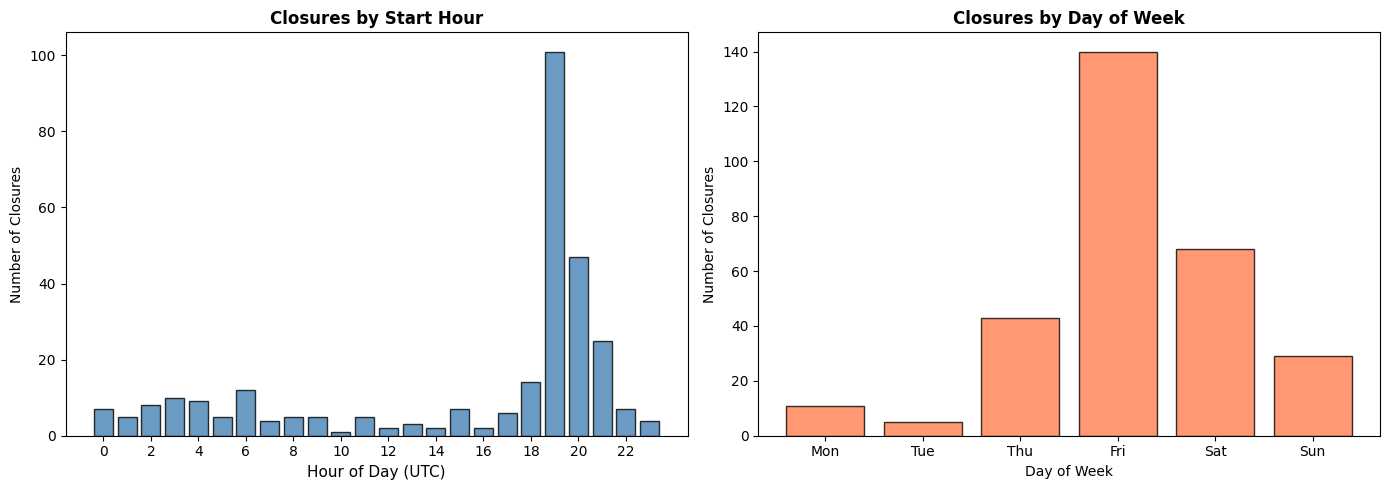

In [ ]:
road_df["start_hour"] = road_df["start_time_dt"].dt.hour
road_df["start_dow"]  = road_df["start_time_dt"].dt.dayofweek   # 0=Mon
road_df["start_date"] = road_df["start_time_dt"].dt.date

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By hour of day
hour_counts = road_df["start_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color="steelblue",
            edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Hour of Day (UTC)", fontsize=11)
axes[0].set_ylabel("Number of Closures")
axes[0].set_title("Closures by Start Hour", fontweight="bold")
axes[0].set_xticks(range(0, 24, 2))

# By day of week
dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_counts = road_df["start_dow"].value_counts().sort_index()
axes[1].bar([dow_map[i] for i in dow_counts.index], dow_counts.values,
            color="coral", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Closures")
axes[1].set_title("Closures by Day of Week", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_01/temporal_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

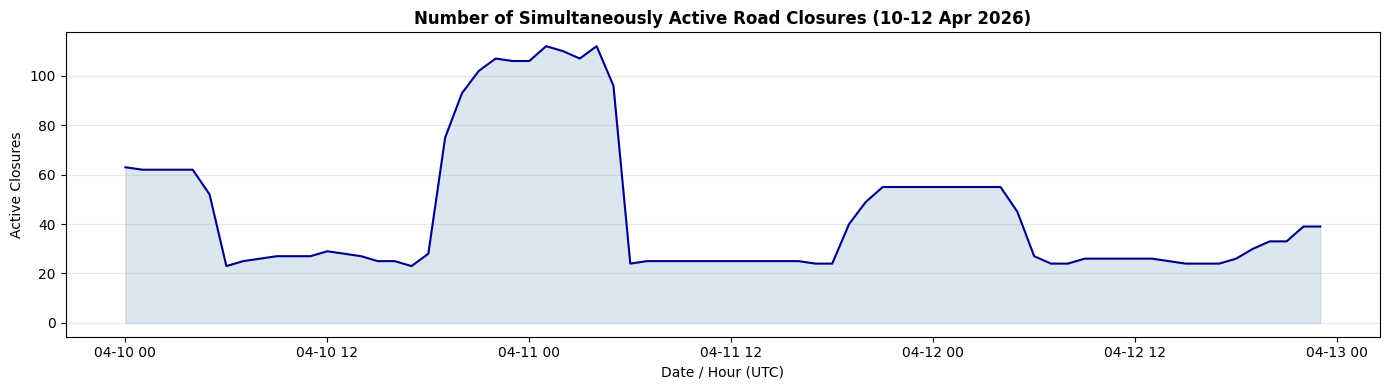

In [ ]:
# Closures active at each hour across the window
# Build a timeline: for each hour, count how many closures are active
import numpy as np

hours = pd.date_range(start="2026-04-10 00:00", end="2026-04-12 23:00",
                      freq="h", tz="UTC")

active_counts = []
for h in hours:
    active = road_df[
        (road_df["start_time_dt"] <= h) &
        (road_df["end_time_dt"] >= h)
    ]
    active_counts.append(len(active))

plt.figure(figsize=(14, 4))
plt.plot(hours, active_counts, color="darkblue", linewidth=1.5)
plt.fill_between(hours, active_counts, alpha=0.2, color="steelblue")
plt.xlabel("Date / Hour (UTC)")
plt.ylabel("Active Closures")
plt.title("Number of Simultaneously Active Road Closures (10-12 Apr 2026)", fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_01/active_closures_timeline.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Duration Analysis

Closure duration (end_time − start_time) determines how long a given section of road is unavailable. Short closures (minutes to hours) represent acute incidents; long closures (overnight, multi-day) represent planned maintenance windows. Duration is relevant to modelling because longer closures may produce sustained rather than acute rail impacts.

In [ ]:
road_df["duration_hours"] = (
    road_df["end_time_dt"] - road_df["start_time_dt"]
).dt.total_seconds() / 3600

print("Duration statistics (hours):")
print(road_df["duration_hours"].describe().round(2))
print()
print(f"Closures with duration <= 2 hours:  {(road_df['duration_hours'] <= 2).sum():,}")
print(f"Closures with duration 2-12 hours:  {((road_df['duration_hours'] > 2) & (road_df['duration_hours'] <= 12)).sum():,}")
print(f"Closures with duration 12-24 hours: {((road_df['duration_hours'] > 12) & (road_df['duration_hours'] <= 24)).sum():,}")
print(f"Closures with duration > 24 hours:  {(road_df['duration_hours'] > 24).sum():,}")

Duration statistics (hours):
count      296.00
mean       506.65
std       2298.04
min          0.25
25%          0.25
50%          9.00
75%         10.00
max      17544.00
Name: duration_hours, dtype: float64

Closures with duration <= 2 hours:  96
Closures with duration 2-12 hours:  173
Closures with duration 12-24 hours: 0
Closures with duration > 24 hours:  27


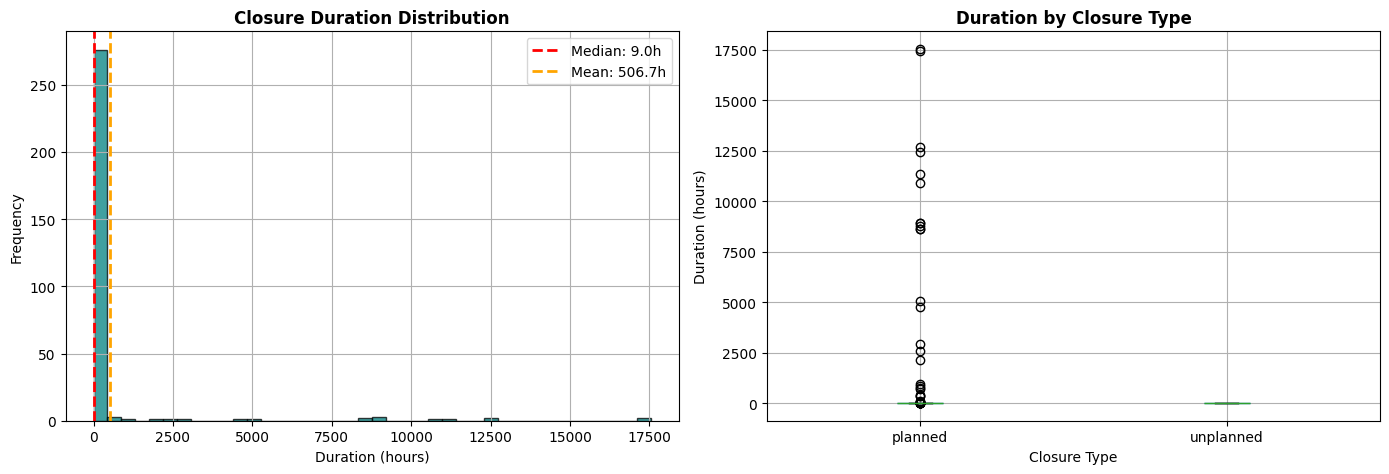

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
road_df["duration_hours"].hist(bins=40, ax=axes[0], edgecolor="black",
                                alpha=0.75, color="teal")
axes[0].set_xlabel("Duration (hours)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Closure Duration Distribution", fontweight="bold")
axes[0].axvline(road_df["duration_hours"].median(), color="red", linestyle="--",
                lw=2, label=f"Median: {road_df['duration_hours'].median():.1f}h")
axes[0].axvline(road_df["duration_hours"].mean(), color="orange", linestyle="--",
                lw=2, label=f"Mean: {road_df['duration_hours'].mean():.1f}h")
axes[0].legend()

# By closure type
road_df.boxplot(column="duration_hours", by="closure_type", ax=axes[1],
                patch_artist=True)
axes[1].set_title("Duration by Closure Type", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Duration (hours)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_01/duration_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Spatial Distribution

Visualising where closures occur reveals geographic concentration and informs whether the 10-25 km distance band captures closures near significant rail corridors.

In [ ]:
print("Spatial extent of closures:")
print(f"  Latitude  range: {road_df['closure_lat'].min():.4f} — {road_df['closure_lat'].max():.4f}")
print(f"  Longitude range: {road_df['closure_lon'].min():.4f} — {road_df['closure_lon'].max():.4f}")
print(f"  Missing lat/lon: {road_df['closure_lat'].isna().sum()}")

Spatial extent of closures:
  Latitude  range: 50.2359 — 55.0664
  Longitude range: -5.2584 — 1.7230
  Missing lat/lon: 0


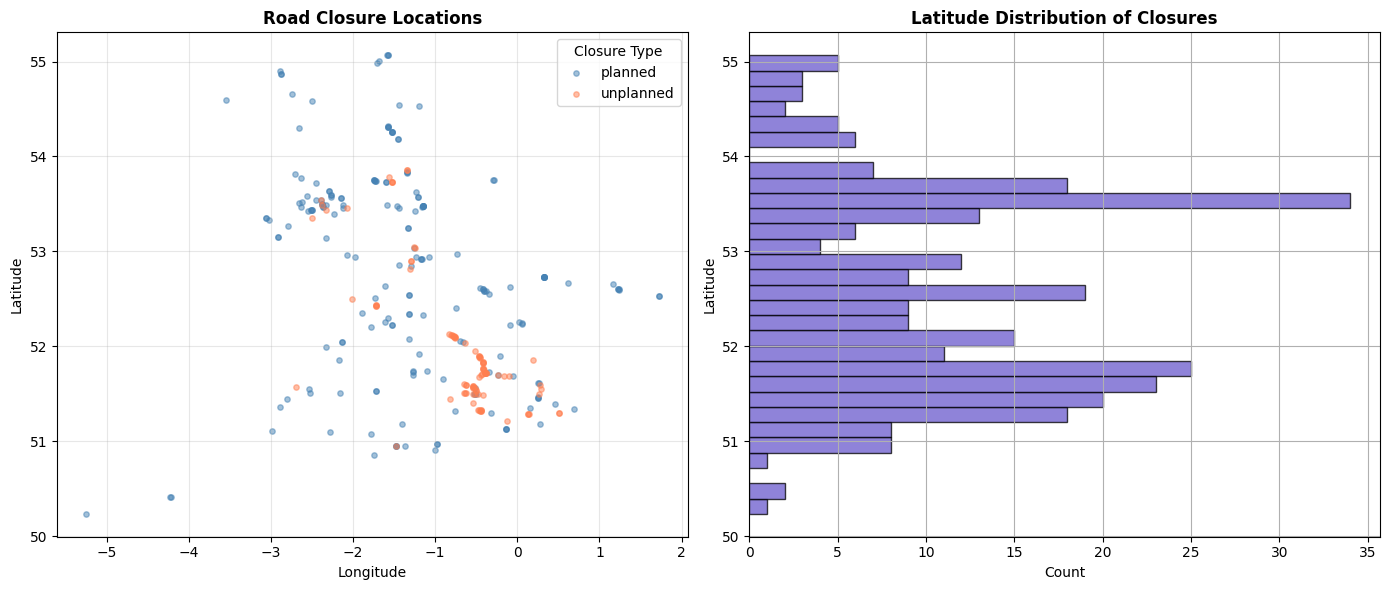

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

color_map = {"planned": "steelblue", "unplanned": "coral"}

for ctype, grp in road_df.groupby("closure_type"):
    axes[0].scatter(grp["closure_lon"], grp["closure_lat"],
                    alpha=0.5, s=15, label=ctype, color=color_map.get(ctype, "grey"))

axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Road Closure Locations", fontweight="bold")
axes[0].legend(title="Closure Type")
axes[0].grid(alpha=0.3)

# Density: latitude histogram
road_df["closure_lat"].hist(bins=30, ax=axes[1], color="slateblue",
                             edgecolor="black", alpha=0.75, orientation="horizontal")
axes[1].set_ylabel("Latitude")
axes[1].set_xlabel("Count")
axes[1].set_title("Latitude Distribution of Closures", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_01/spatial_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

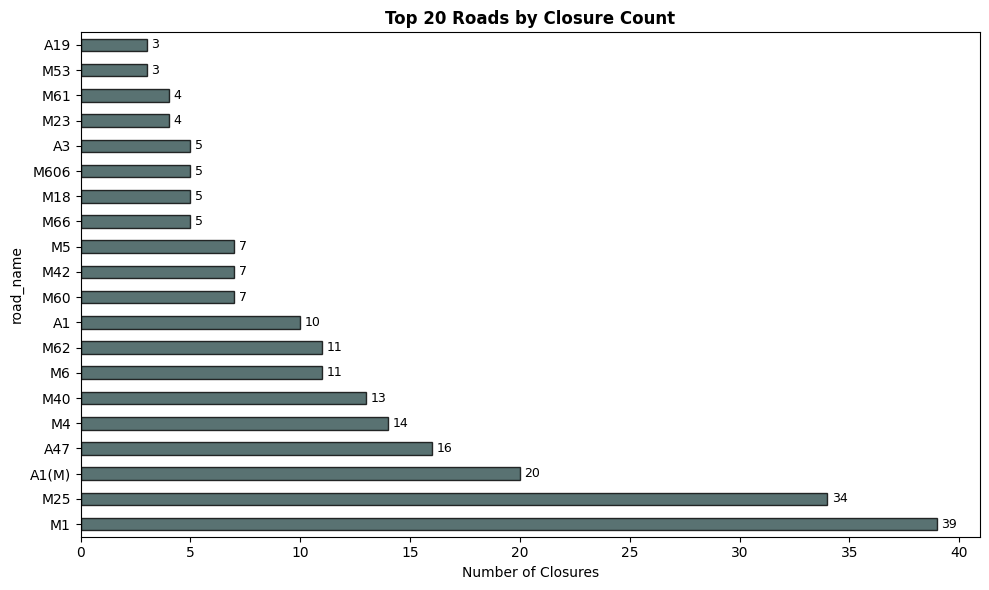

In [ ]:
# Road name frequency: which roads have the most closures?
if "road_name" in road_df.columns:
    road_counts = road_df["road_name"].value_counts().head(20)
    plt.figure(figsize=(10, 6))
    road_counts.plot(kind="barh", color="darkslategray", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Closures")
    plt.title("Top 20 Roads by Closure Count", fontweight="bold")
    for i, v in enumerate(road_counts.values):
        plt.text(v + 0.2, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_01/top_roads.png", dpi=200, bbox_inches="tight")
    plt.show()

## 8. Lanes Closed Distribution

The number of lanes closed provides a proxy for disruption severity. A single-lane closure on a dual carriageway is far less disruptive than a full road closure.

In [ ]:
if "lanes_closed" in road_df.columns:
    lanes = road_df["lanes_closed"].dropna()
    print("Lanes closed statistics:")
    print(lanes.describe().round(2))
    print()
    print(lanes.value_counts().sort_index().to_string())

Lanes closed statistics:
count    296.00
mean       1.15
std        1.14
min        0.00
25%        0.00
50%        1.00
75%        2.00
max        4.00
Name: lanes_closed, dtype: float64

lanes_closed
0    107
1     91
2     60
3     24
4     14


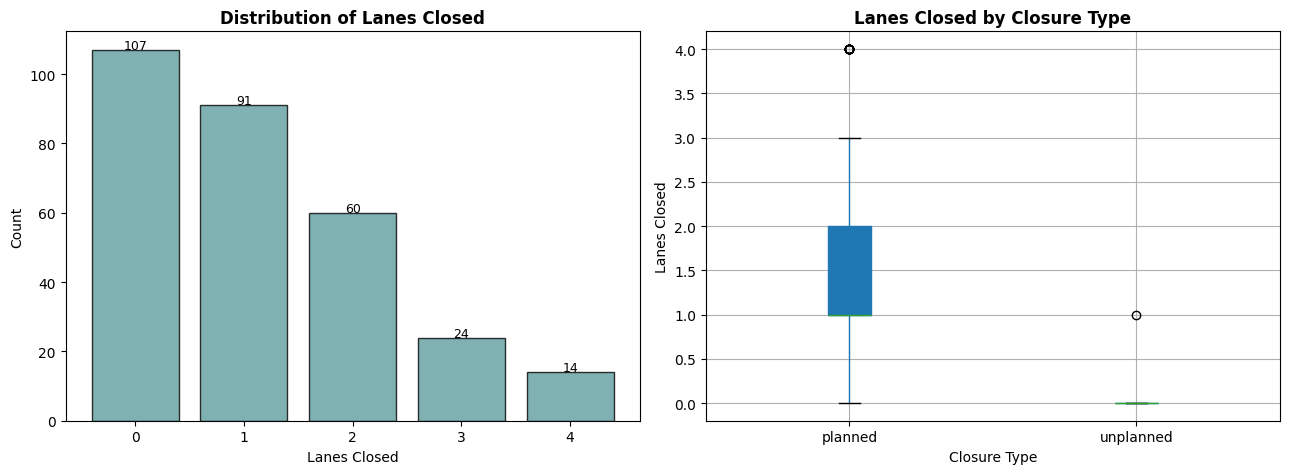

In [ ]:
if "lanes_closed" in road_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    lc_counts = road_df["lanes_closed"].value_counts().sort_index()
    axes[0].bar(lc_counts.index.astype(str), lc_counts.values,
                color="cadetblue", edgecolor="black", alpha=0.8)
    axes[0].set_xlabel("Lanes Closed")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Lanes Closed", fontweight="bold")
    for i, v in enumerate(lc_counts.values):
        axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

    road_df.boxplot(column="lanes_closed", by="closure_type", ax=axes[1],
                    patch_artist=True)
    axes[1].set_title("Lanes Closed by Closure Type", fontweight="bold")
    axes[1].set_xlabel("Closure Type")
    axes[1].set_ylabel("Lanes Closed")
    plt.suptitle("")

    plt.tight_layout()
    plt.savefig("figures/eda_01/lanes_closed.png", dpi=200, bbox_inches="tight")
    plt.show()

## 9. Summary of Findings and Cleaned Output

Key findings from this EDA to carry forward into the main analysis:

- Total road closures retrieved: **296** over 72 hours (10-12 April 2026)
- Validity statuses include planned, active, and suspended — all retained in the pipeline
- Cause types are dominated by `roadMaintenance`; a small proportion are incident-driven
- Duration varies widely; planned closures tend to be overnight windows (10pm–5am)
- Spatial coverage spans primarily England with concentration along motorway and A-road corridors
- No critical fields (lat, lon, start_time, end_time, closure_type) are systematically missing

**Cleaning decisions applied below:**
- Convert timestamps to UTC datetime
- Compute `duration_hours` as a derived feature
- Drop rows where both `closure_lat` and `closure_lon` are null (if any)


In [ ]:
# Build cleaned output
road_clean = road_df.copy()

# Ensure parsed timestamps present
road_clean["start_time_dt"] = pd.to_datetime(road_clean["start_time"], utc=True, errors="coerce")
road_clean["end_time_dt"]   = pd.to_datetime(road_clean["end_time"],   utc=True, errors="coerce")

# Derived feature
road_clean["duration_hours"] = (
    road_clean["end_time_dt"] - road_clean["start_time_dt"]
).dt.total_seconds() / 3600

# Drop rows missing spatial coordinates
before = len(road_clean)
road_clean = road_clean.dropna(subset=["closure_lat", "closure_lon"])
print(f"Dropped {before - len(road_clean)} rows missing coordinates.")
print(f"Final road closures dataset: {len(road_clean):,} rows")

# Save
road_clean["situation_id"] = road_clean["situation_id"].astype("string")
road_clean.to_parquet("./data/processed/road_closures_clean.parquet", index=False)
print("Saved to data/processed/road_closures_clean.parquet")

Dropped 0 rows missing coordinates.
Final road closures dataset: 296 rows
Saved to data/processed/road_closures_clean.parquet


In [ ]:
print("\nColumn summary of saved dataset:")
road_clean.info()


Column summary of saved dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   situation_id     296 non-null    string             
 1   record_id        296 non-null    object             
 2   start_time       296 non-null    object             
 3   end_time         296 non-null    object             
 4   validity_status  296 non-null    object             
 5   cause_type       296 non-null    object             
 6   source           296 non-null    object             
 7   road_name        296 non-null    object             
 8   lanes_closed     296 non-null    int64              
 9   closure_lat      296 non-null    float64            
 10  closure_lon      296 non-null    float64            
 11  poslist          296 non-null    object             
 12  ingestion_time   296 non-null    object     

array([datetime.date(2026, 4, 11), datetime.date(2026, 4, 9),
       datetime.date(2026, 4, 10), datetime.date(2026, 3, 2),
       datetime.date(2026, 3, 17), datetime.date(2026, 3, 31),
       datetime.date(2025, 5, 20), datetime.date(2026, 3, 23),
       datetime.date(2026, 4, 12), datetime.date(2026, 3, 30),
       datetime.date(2025, 10, 30), datetime.date(2026, 3, 3),
       datetime.date(2026, 2, 27), datetime.date(2025, 12, 13),
       datetime.date(2026, 1, 12), datetime.date(2025, 10, 6),
       datetime.date(2025, 11, 13), datetime.date(2025, 11, 17),
       datetime.date(2025, 11, 29), datetime.date(2026, 4, 5),
       datetime.date(2026, 4, 6)], dtype=object)